# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Datasets

In [3]:
Path = ("/Users/mehreenwerth/Desktop/citibike-weather-2022")

In [5]:
weather = pd.read_csv("data_processed/weather_lga_2022.csv")
daily = pd.read_csv("data_processed/daily_citibike_2022.csv")

weather["date"] = pd.to_datetime(weather["date"])
daily["date"] = pd.to_datetime(daily["date"])

df = weather.merge(daily, on="date", how="left")
df["trip_count"] = df["trip_count"].fillna(0).astype(int)

df["TAVG_C"] = df["TAVG"] / 10

# Setting the Theme

In [6]:
sns.set_theme(style="whitegrid", palette="Set2")

# Top 20 Starting Stations

In [11]:
trips_raw = pd.read_csv("data_processed/citibike_master_2022.csv", low_memory=False)

In [12]:
trips_raw.shape, trips_raw.columns

((29838806, 5),
 Index(['started_at', 'ended_at', 'start_station_name', 'member_casual',
        'duration_min'],
       dtype='object'))

In [17]:
trips_raw.shape, list(trips_raw.columns)

((29838806, 5),
 ['started_at',
  'ended_at',
  'start_station_name',
  'member_casual',
  'duration_min'])

In [18]:
top20 = (
    trips_raw["start_station_name"]
    .dropna()
    .value_counts()
    .head(20)
    .reset_index()
)
top20.columns = ["start_station_name", "count"]

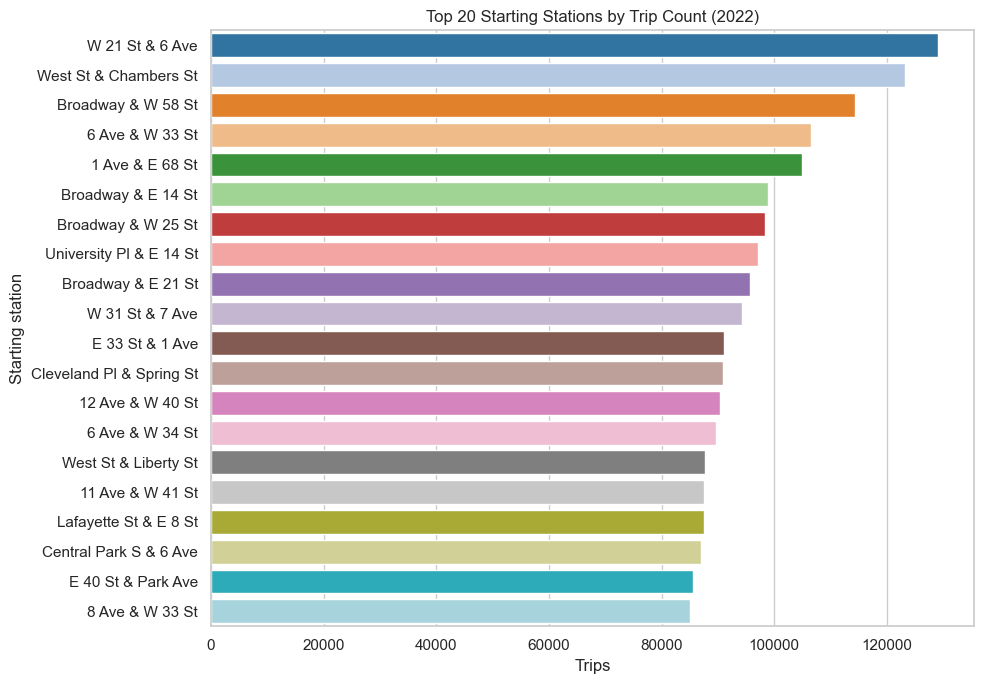

In [34]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top20,
    y="start_station_name",
    x="count",
    hue="start_station_name",
    palette="tab20",
    legend=False              
)

plt.title("Top 20 Starting Stations by Trip Count (2022)")
plt.xlabel("Trips")
plt.ylabel("Starting station")
plt.tight_layout()

plt.savefig("top20_starting_stations.png", dpi=300, bbox_inches="tight")
plt.show()

### This bar chart shows the 20 most frequently used starting stations in 2022. A small number of stations account for a very large share of trips, indicating strong demand in key high-traffic areas such as Midtown and Lower Manhattan. The distribution suggests that Citi Bike usage is concentrated around major commuting and commercial corridors rather than evenly spread across the city.

# Daily Trips vs Temperature

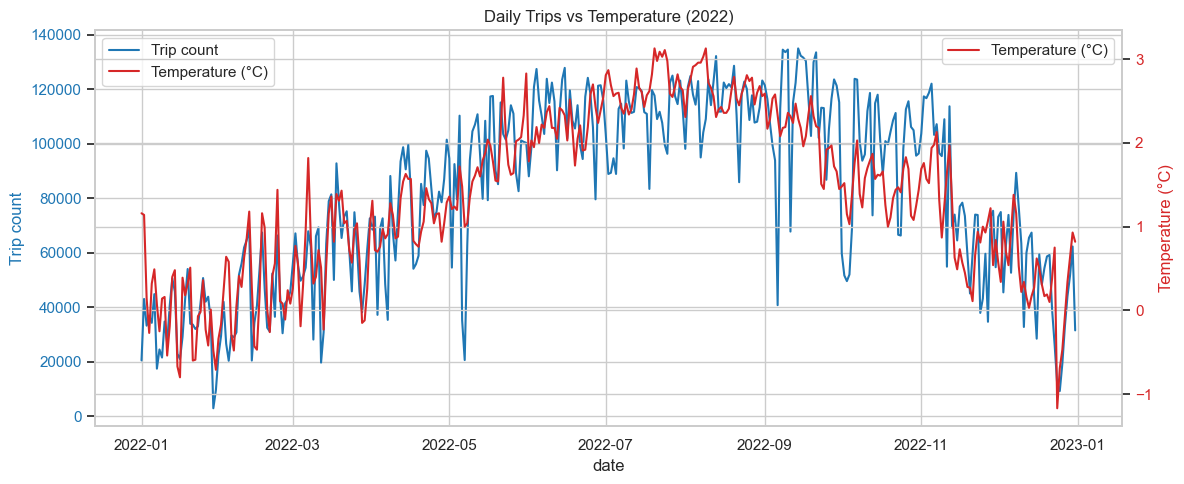

<Figure size 640x480 with 0 Axes>

In [32]:
df_plot = df.sort_values("date")

fig, ax1 = plt.subplots(figsize=(12, 5))

sns.lineplot(data=df_plot, x="date", y="trip_count", ax=ax1, color="tab:blue", label="Trip count")
ax1.set_ylabel("Trip count", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")

ax2 = ax1.twinx()
sns.lineplot(data=df_plot, x="date", y="TAVG_C", ax=ax2, color="tab:red", label="Temperature (°C)")
ax2.set_ylabel("Temperature (°C)", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

ax1.set_title("Daily Trips vs Temperature (2022)")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

plt.savefig("seasonality_dual_axis.png", dpi=300, bbox_inches="tight")

### The dual-axis line chart shows a clear seasonal pattern: bike trips increase as average temperature rises and decrease during colder months. Trip counts peak during late spring and summer when temperatures are highest. This suggests that weather is strongly correlated with bike usage, with warmer conditions encouraging more frequent riding.

# Duration

In [21]:
trips_raw["started_at"] = pd.to_datetime(trips_raw["started_at"])
trips_raw["ended_at"] = pd.to_datetime(trips_raw["ended_at"])
trips_raw["duration_min"] = (trips_raw["ended_at"] - trips_raw["started_at"]).dt.total_seconds() / 60

trips_box = trips_raw[(trips_raw["duration_min"] > 0) & (trips_raw["duration_min"] < 180)]

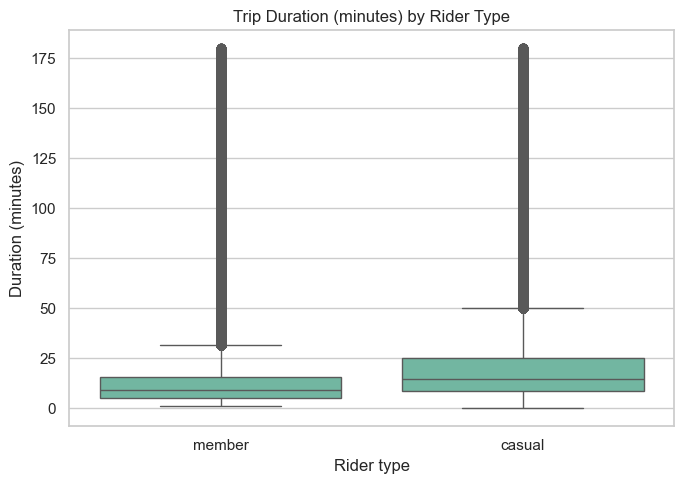

<Figure size 640x480 with 0 Axes>

In [31]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=trips_box, x="member_casual", y="duration_min")
plt.title("Trip Duration (minutes) by Rider Type")
plt.xlabel("Rider type")
plt.ylabel("Duration (minutes)")
plt.tight_layout()
plt.show()
plt.savefig("boxplot_duration_member_type.png", dpi=300, bbox_inches="tight")

### The box plot compares trip durations between members and casual riders. Casual riders generally have a higher median duration and a wider interquartile range, indicating that they take longer and more variable trips. Members tend to have shorter and more consistent ride durations, which likely reflects commuting behavior. The presence of outliers in both groups suggests occasional long recreational trips.

# FacetGrid

In [27]:
trips_box = trips_raw[
    (trips_raw["duration_min"] > 0) &
    (trips_raw["duration_min"] < 180)
].copy()

In [29]:
trips_raw["started_at"] = pd.to_datetime(trips_raw["started_at"], errors="coerce")

trips_box = trips_raw[
    (trips_raw["duration_min"] > 0) &
    (trips_raw["duration_min"] < 180) &
    (trips_raw["started_at"].notna())
].copy()

trips_box["month"] = trips_box["started_at"].dt.month

trips_box.columns

Index(['started_at', 'ended_at', 'start_station_name', 'member_casual',
       'duration_min', 'month'],
      dtype='object')

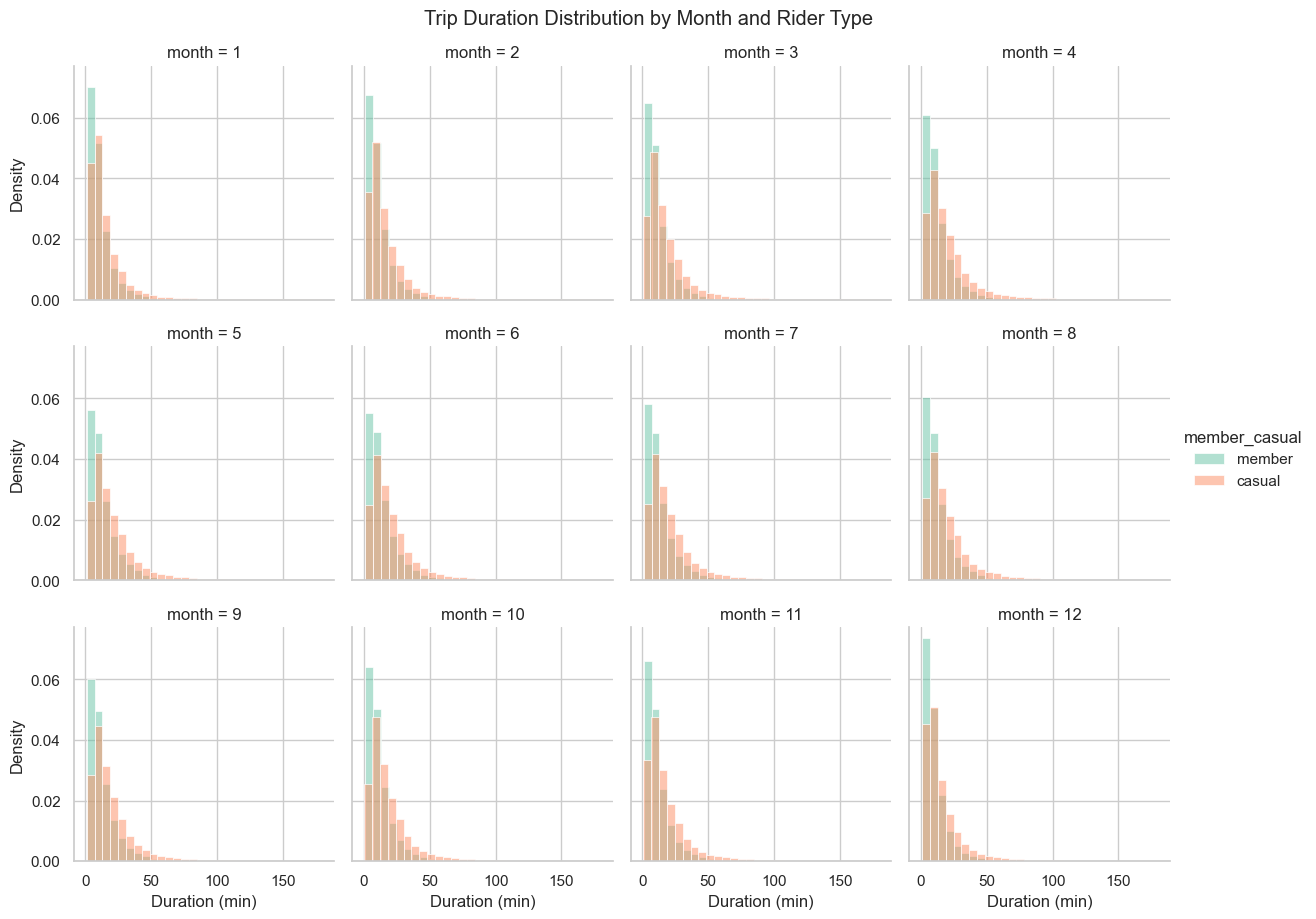

In [30]:
g = sns.FacetGrid(
    trips_box,
    col="month",
    col_wrap=4,
    hue="member_casual",
    sharex=True,
    sharey=True,
    height=3
)

g.map(sns.histplot, "duration_min", bins=30, stat="density", common_norm=False, alpha=0.5)
g.add_legend()
g.set_axis_labels("Duration (min)", "Density")
g.fig.suptitle("Trip Duration Distribution by Month and Rider Type", y=1.02)


g.savefig("facetgrid_duration_by_month.png", dpi=300, bbox_inches="tight")

plt.show()

### The FacetGrid shows how trip duration distributions change across months for members and casual riders. In warmer months, the distributions appear slightly more spread out with heavier right tails, suggesting an increase in longer recreational rides. Casual riders consistently show longer-duration trips across most months, while member trips remain more concentrated at shorter durations. This reinforces the idea that members primarily use Citi Bike for routine transportation, while casual users are more recreational.